In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Student Social Media And Mental Health Impact.csv")

In [4]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [5]:
#  Total Number of Rows and Columns
df.shape

(5000, 13)

1. String values ko object kehte hai.
2. So we convert all object columns to format of 0 and 1.
3. Make sure there a no duplictaes so as to make model more unbaised.
4. Jaha object hai perform encoding.

In [6]:
df.isnull().sum()
# No null values

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [7]:
df.duplicated().sum()
# 2 duplicated rows

np.int64(2)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Country                  5000 non-null   str    
 3   Academic_Level           5000 non-null   str    
 4   Most_Used_Platform       5000 non-null   str    
 5   Purpose_Of_Use           5000 non-null   str    
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   str    
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 507.9 KB


In [9]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


# EDA (Exploratory Data Analysis)

Histgoram helps us to visualize the distribution of data,shape of data.

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

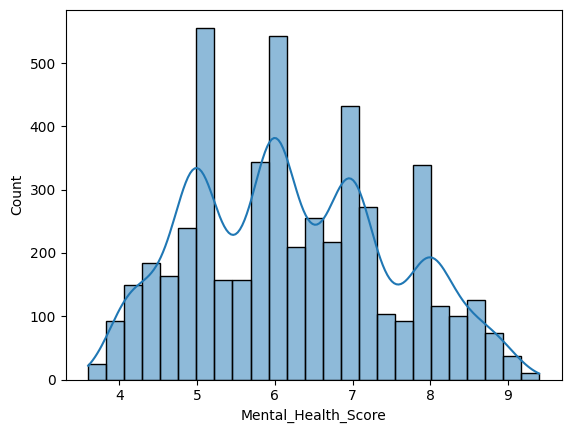

In [10]:
sns.histplot(df["Mental_Health_Score"],kde=True)

In [11]:
# Correlation : how 2 columns are related to each other. Postively or negatively.
df.corr

<bound method DataFrame.corr of       Age  Gender Country Academic_Level Most_Used_Platform Purpose_Of_Use  \
0      21    Male   Other  Undergraduate           Facebook     Networking   
1      23  Female   Other       Graduate           LinkedIn      Education   
2      22    Male  Canada  Undergraduate          Instagram  Entertainment   
3      18    Male   Other    High School           Snapchat  Entertainment   
4      24  Female   Other       Graduate           Facebook     Networking   
...   ...     ...     ...            ...                ...            ...   
4995   18  Female   Other    High School            YouTube      Education   
4996   18  Female   Other    High School            YouTube      Education   
4997   19  Female   India  Undergraduate           LinkedIn      Education   
4998   18    Male   Other    High School          Instagram  Entertainment   
4999   19    Male   China  Undergraduate             WeChat  Entertainment   

      Avg_Daily_Usage_Hours  Da

<Axes: >

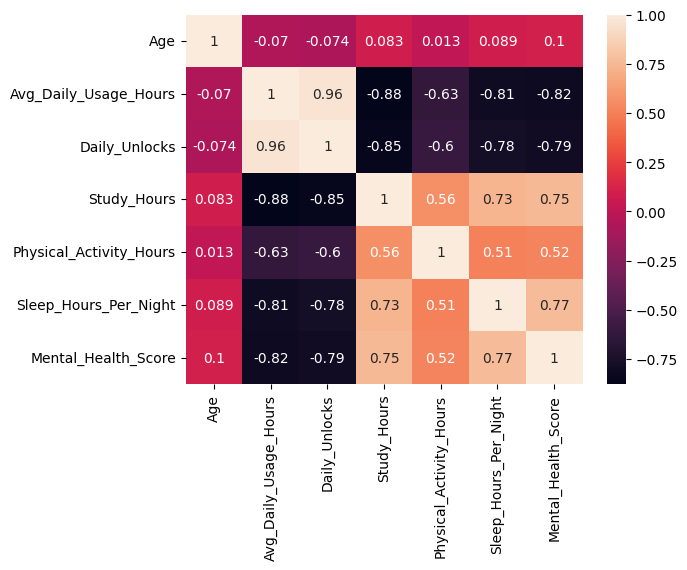

In [12]:
# heatmap is use to show correlation between 2 numerical columns.

sns.heatmap(df.corr(numeric_only=True),annot=True)

### Stress Level VS Mental health Score

In [13]:
df["Stress_Level"].unique()


<StringArray>
['Medium', 'Low', 'Very High', 'High']
Length: 4, dtype: str

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

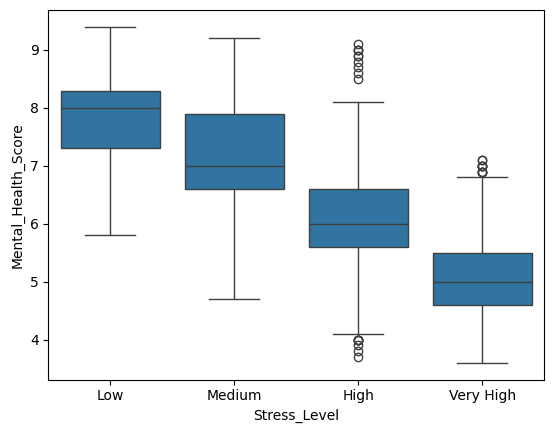

In [18]:
order = ['Low', 'Medium', 'High', 'Very High']
sns.boxplot(x='Stress_Level',y='Mental_Health_Score',data=df,order=order)

### Daily Usage Hours VS Mental Heath Score
More time on Social media means Less Score

In [19]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='str')

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

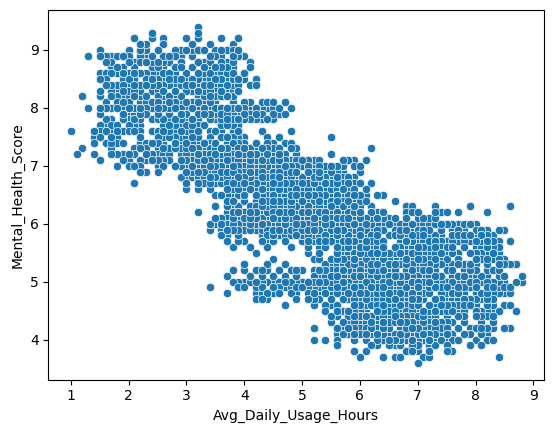

In [22]:
sns.scatterplot(x="Avg_Daily_Usage_Hours",y='Mental_Health_Score',data=df)

### Sleep Hours VS Mental Health Score
Proper Sleep means more Score

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

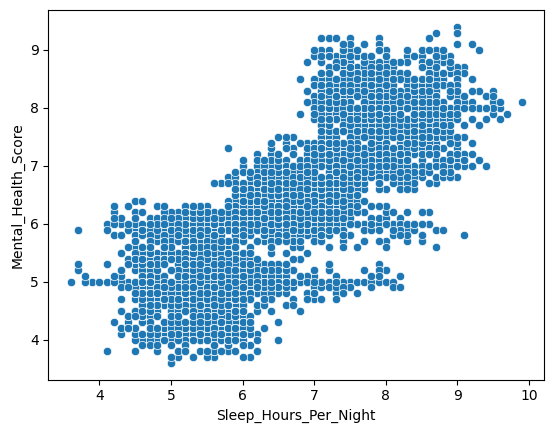

In [23]:
sns.scatterplot(x="Sleep_Hours_Per_Night",y="Mental_Health_Score",data=df)

### Most Used Platform by Users

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

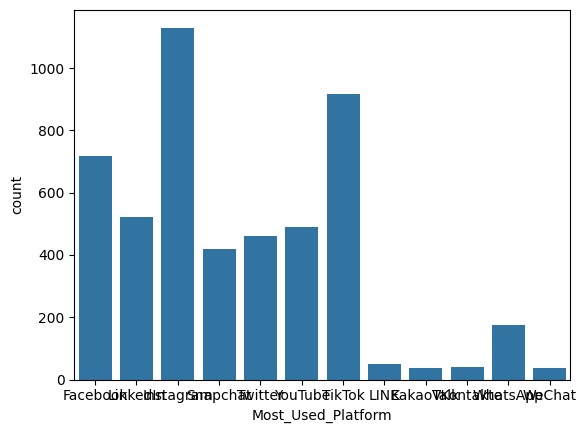

In [38]:
sns.countplot(x="Most_Used_Platform",data=df)

In [32]:
platform = df["Most_Used_Platform"].value_counts()
platform

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

## Checking Outliers

In [46]:
# Function/formula to identify outliers

num_features = df.select_dtypes(include="number")
num_features

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
0,21,4.0,134,4.5,2.2,6.7,6.8
1,23,1.6,73,7.0,2.4,8.6,7.6
2,22,4.6,166,4.0,1.8,6.7,7.0
3,18,7.0,220,1.0,1.7,5.4,5.3
4,24,7.5,237,1.0,1.1,5.0,4.4
...,...,...,...,...,...,...,...
4995,18,1.9,89,6.1,2.2,7.9,7.9
4996,18,6.6,216,2.3,1.8,6.0,4.7
4997,19,3.8,151,5.4,1.4,7.5,7.0
4998,18,3.8,119,4.0,1.5,6.4,6.7


In [56]:
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3-Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = (num_features < lower) | (num_features > upper)
print(outliers.sum())
# IQR = Inter quantile range

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64
